In [2]:
!pip install transformer_lens einops datasets --quiet

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.4/56.4 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 105.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 821.0/821.0 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 85.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 127.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 58.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.0/571.0 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 62.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━

In [7]:
!pip install --force-reinstall torch torchvision


  Using cached torch-2.12.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (31 kB)
  Using cached cuda_toolkit-13.0.2-py2.py3-none-any.whl.metadata (9.4 kB)
  Using cached nvidia_cublas-13.1.1.3-py3-none-manylinux_2_27_x86_64.whl.metadata (1.8 kB)
  Using cached cuda_bindings-13.3.1-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (2.5 kB)
  Using cached nvidia_cudnn_cu13-9.20.0.48-py3-none-manylinux_2_27_x86_64.whl.metadata (1.9 kB)
  Using cached nvidia_cusparselt_cu13-0.8.1-py3-none-manylinux2014_x86_64.whl.metadata (12 kB)
  Using cached nvidia_nccl_cu13-2.29.7-py3-none-manylinux_2_18_x86_64.whl.metadata (2.1 kB)
  Using cached nvidia_nvshmem_cu13-3.4.5-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (2.1 kB)
  Using cached triton-3.7.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (1.7 kB)
  Using cached nvidia_cuda_runtime-13.0.96-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (1.7 kB)
  Using cached nv

In [1]:
# %% ── Cell 2: Imports ───────────────────────────────────────────────────────

import torch
import numpy as np
from transformer_lens import HookedTransformer
from datasets import load_dataset

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cuda
PyTorch version: 2.12.0+cu130


In [3]:
# %% ── Cell 3: Load GPT-2 Small ──────────────────────────────────────────────
# HookedTransformer is TransformerLens's version of GPT-2.
# Key difference from HuggingFace's GPT2: it exposes named hooks at every
# internal computation point (residual stream, attention output, MLP output).
#
# We are NOT training GPT-2. Its weights are frozen from the moment we load it.
# model.eval() + torch.no_grad() ensures no gradients are computed.

model = HookedTransformer.from_pretrained("gpt2", device=device)
model.eval()

print(f"\nModel architecture:")
print(f"  Layers  : {model.cfg.n_layers}")    # 12
print(f"  d_model : {model.cfg.d_model}")     # 768  ← size of each activation vector
print(f"  n_heads : {model.cfg.n_heads}")     # 12
print(f"  d_mlp   : {model.cfg.d_mlp}")       # 3072
print(f"  Vocab   : {model.cfg.d_vocab}")     # 50257
print(f"  Params  : {sum(p.numel() for p in model.parameters()):,}")  # ~117M

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Loaded pretrained model gpt2 into HookedTransformer

Model architecture:
  Layers  : 12
  d_model : 768
  n_heads : 12
  d_mlp   : 3072
  Vocab   : 50257
  Params  : 163,049,041


In [4]:
# %% ── Cell 4: Sanity check — one forward pass ───────────────────────────────
# Just verifying the model loaded correctly. We feed a sentence, check the
# top-5 predictions for the next token. This is plain GPT-2 inference.

text = "The cat sat on the"
tokens = model.to_tokens(text)

print(f"Input     : '{text}'")
print(f"Token IDs : {tokens.tolist()}")
print(f"Tokens    : {model.to_str_tokens(text)}")

with torch.no_grad():
    logits = model(tokens)   # shape: [batch=1, seq_len=6, vocab_size=50257]

top5 = logits[0, -1].topk(5)
print(f"\nTop 5 predictions for next token:")
for score, tok_id in zip(top5.values, top5.indices):
    print(f"  '{model.to_string(tok_id):<12}' logit = {score:.2f}")

Input     : 'The cat sat on the'
Token IDs : [[50256, 464, 3797, 3332, 319, 262]]
Tokens    : ['<|endoftext|>', 'The', ' cat', ' sat', ' on', ' the']

Top 5 predictions for next token:
  ' floor      ' logit = 14.88
  ' bed        ' logit = 14.56
  ' couch      ' logit = 14.36
  ' ground     ' logit = 14.17
  ' edge       ' logit = 14.14


In [5]:
# %% ── Cell 5: Understand hooks — intercept layer 8's residual stream ────────
# The "residual stream" is the main highway of information in GPT-2.
# At every layer, attention + MLP outputs are *added* to this stream.
# hook_resid_post is the stream state AFTER layer 8 has finished processing.
#
# run_with_hooks() lets us attach functions that run during the forward pass.
# The function receives the activation tensor and can save or modify it.
# Returning it unchanged means GPT-2's behaviour is unaffected.
#
# Activation shape: [batch, seq_len, d_model=768]
# One 768-dim vector per token position, per sentence.

captured = {}

def save_activation(value, hook):
    captured[hook.name] = value.detach().cpu()
    return value   # must return value unchanged

with torch.no_grad():
    model.run_with_hooks(
        tokens,
        fwd_hooks=[("blocks.8.hook_resid_post", save_activation)]
    )

resid = captured["blocks.8.hook_resid_post"]
print(f"Residual stream shape : {resid.shape}")
# → torch.Size([1, 6, 768])
# Meaning: 1 sentence, 6 tokens, 768 dimensions each.
#
# For our SAE we will use the activation at the *last* token position of each
# sentence — that position has "seen" the whole context.
print(f"Last token vector (dim 0–7): {resid[0, -1, :8].numpy().round(3)}")

Residual stream shape : torch.Size([1, 6, 768])
Last token vector (dim 0–7): [-1.608  1.544 -7.491  0.916 -0.992 -4.709 -0.118  0.636]


In [8]:
# %% ── Cell 6: Collect activations at scale ──────────────────────────────────
# Plan:
#   - Load 2000 sentences from OpenWebText (a standard GPT-2 training corpus)
#   - Run each through GPT-2, save the layer-8 residual stream at the last token
#   - Stack into a matrix of shape [N, 768]
#
# Why 2000? It's enough to train an SAE that works and analyse its features.
# For a publication-quality SAE you'd use 500k+ vectors, but 2000 is perfect
# to get the pipeline running end-to-end in a single session.
#
# Why layer 8 of 12? Mid-to-late layers are most interesting for SAEs:
# early layers handle syntax, late layers handle output. Layer 8 tends to hold
# rich semantic content. You can change LAYER to experiment later.

LAYER = 8
N_SAMPLES = 2000
MAX_TOKENS = 64    # cap each sentence at 64 tokens to keep the loop fast

# Load dataset (downloads ~40 MB once, cached afterwards)
# REPLACE everything from "Load dataset" down to texts = texts[:N_SAMPLES]
# WITH THIS:

import urllib.request

print("Downloading text...")
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
with urllib.request.urlopen(url) as r:
    raw = r.read().decode("utf-8")

# Slide a window across the text to get 2000 overlapping 200-char chunks
texts = []
for i in range(0, len(raw) - 200, 50):   # stride=50 → lots of overlap, diverse contexts
    chunk = raw[i : i + 200].strip()
    if len(chunk) > 80:                   # skip very short end-of-file scraps
        texts.append(chunk)
    if len(texts) >= N_SAMPLES:
        break

print(f"Loaded {len(texts)} text chunks")

all_activations = []
skipped = 0

for i, text in enumerate(texts):
    if i % 200 == 0:
        print(f"  {i:4d}/{len(texts)} processed  ({len(all_activations)} saved)")

    try:
        tokens = model.to_tokens(text, prepend_bos=True)
        tokens = tokens[:, :MAX_TOKENS]   # [1, ≤64]

        captured_local = {}
        def _hook(value, hook):
            captured_local[hook.name] = value.detach().cpu()
            return value

        with torch.no_grad():
            model.run_with_hooks(
                tokens,
                fwd_hooks=[(f"blocks.{LAYER}.hook_resid_post", _hook)]
            )

        # Shape: [1, seq_len, 768] → take last token → [768]
        act = captured_local[f"blocks.{LAYER}.hook_resid_post"][0, -1, :].float()
        all_activations.append(act)

    except Exception as e:
        skipped += 1

print(f"\nDone. Collected {len(all_activations)} vectors, skipped {skipped}.")

activation_matrix = torch.stack(all_activations)   # [N, 768]
print(f"Matrix shape : {activation_matrix.shape}")
print(f"Mean         : {activation_matrix.mean():.4f}")
print(f"Std          : {activation_matrix.std():.4f}")
print(f"Min / Max    : {activation_matrix.min():.4f} / {activation_matrix.max():.4f}")

Loaded 2000 text chunks
     0/2000 processed  (0 saved)
   200/2000 processed  (200 saved)
   400/2000 processed  (400 saved)
   600/2000 processed  (600 saved)
   800/2000 processed  (800 saved)
  1000/2000 processed  (1000 saved)
  1200/2000 processed  (1200 saved)
  1400/2000 processed  (1400 saved)
  1600/2000 processed  (1600 saved)
  1800/2000 processed  (1800 saved)

Done. Collected 2000 vectors, skipped 0.
Matrix shape : torch.Size([2000, 768])
Mean         : -0.0000
Std          : 4.3604
Min / Max    : -59.1060 / 84.0414


In [9]:
# %% ── Cell 7: Save to disk ──────────────────────────────────────────────────
# This is the only output of Session 01. Session 02 will load this file
# and train a Sparse Autoencoder on it — GPT-2 never needs to run again.

save_path = "layer8_activations.pt"
torch.save(activation_matrix, save_path)

size_mb = activation_matrix.numel() * 4 / 1e6   # float32 = 4 bytes
print(f"Saved  → {save_path}")
print(f"Shape  → {activation_matrix.shape}   ({size_mb:.1f} MB)")
print()

# If you're on Colab and want to keep this across sessions, download it:
# from google.colab import files
# files.download(save_path)

Saved  → layer8_activations.pt
Shape  → torch.Size([2000, 768])   (6.1 MB)



In [10]:
# %% ── Cell 8: Quick inspection — what does one vector look like? ────────────
# Before moving on, it helps to build intuition for what we just saved.
# Each row in activation_matrix is a 768-dim vector describing what GPT-2
# "thinks" at layer 8 after reading a sentence.
# Most dimensions are small; a few are strongly activated.
# This is polysemanticity in action — multiple unrelated concepts crammed into
# the same 768 dimensions. That is exactly what the SAE will untangle.

vec = activation_matrix[0]
print("=== Vector 0 inspection ===")
print(f"Shape        : {vec.shape}")
print(f"Min / Max    : {vec.min():.3f} / {vec.max():.3f}")
print(f"Dims > 1.0   : {(vec.abs() > 1.0).sum().item()}")
print(f"Dims > 0.1   : {(vec.abs() > 0.1).sum().item()}")

top10 = vec.abs().topk(10)
print("\nTop 10 most activated dimensions:")
for rank, (val, idx) in enumerate(zip(top10.values, top10.indices), 1):
    signed_val = vec[idx].item()
    print(f"  #{rank:2d}  dim {idx.item():4d}  value = {signed_val:+.4f}")

print("\n✓ Session 01 complete. layer8_activations.pt is ready.")
print("  Next: Session 02 — build and train the Sparse Autoencoder.")

=== Vector 0 inspection ===
Shape        : torch.Size([768])
Min / Max    : -35.079 / 49.581
Dims > 1.0   : 579
Dims > 0.1   : 753

Top 10 most activated dimensions:
  # 1  dim  447  value = +49.5812
  # 2  dim  481  value = +45.6087
  # 3  dim  373  value = -35.0785
  # 4  dim   64  value = -30.2357
  # 5  dim  393  value = +18.7470
  # 6  dim  314  value = -18.3007
  # 7  dim  762  value = +14.1065
  # 8  dim  326  value = +13.9628
  # 9  dim   87  value = -13.0362
  #10  dim   49  value = +11.2185

✓ Session 01 complete. layer8_activations.pt is ready.
  Next: Session 02 — build and train the Sparse Autoencoder.


Here we start session 2 now
# =============================================================================
# SAE Interpretability — Session 02: Build and Train the Sparse Autoencoder
# =============================================================================
# Platform : Google Colab (same session, layer8_activations.pt must be on disk)
# Goal     : Train a Sparse Autoencoder that decomposes 768-dim residual
#            stream vectors into ~3072 sparse, interpretable features.
# Output   : sae_trained.pt  (weights + config)
# Next     : Session 03 — analyse what each feature represents.
# =============================================================================

In [1]:
# %% ── Cell 1: Imports ────────────────────────────────────────────────────────

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


In [2]:
# %% ── Cell 2: Load and normalise activations ─────────────────────────────────
# We normalise by dividing every vector by the dataset mean L2 norm.
# This rescales the data so the mean vector has unit norm.
# Why: it makes the L1 coefficient easier to tune and the loss values
# interpretable. After training, we track this scalar to invert if needed.

acts = torch.load("/content/drive/MyDrive/layer8_activations.pt", map_location=device)   # [2000, 768]
print(f"Raw activations  — shape: {acts.shape}, mean: {acts.mean():.4f}, std: {acts.std():.4f}")

mean_norm = acts.norm(dim=-1).mean()   # scalar ≈ 121 (sqrt(768) * 4.36)
print(f"Mean L2 norm of vectors: {mean_norm:.2f}")

acts_norm = acts / mean_norm           # now mean ||x|| ≈ 1
print(f"Normalised — mean norm: {acts_norm.norm(dim=-1).mean():.4f}")

Raw activations  — shape: torch.Size([2000, 768]), mean: -0.0000, std: 4.3604
Mean L2 norm of vectors: 120.50
Normalised — mean norm: 1.0000


In [3]:
# %% ── Cell 3: Define the Sparse Autoencoder ──────────────────────────────────
# Architecture (standard Anthropic-style SAE):
#
#   Input x ∈ R^{d_model}
#   h = ReLU( W_enc · x  +  b_enc )      ← sparse hidden activations, R^{d_hidden}
#   x̂ = W_dec · h  +  b_dec              ← reconstruction
#
#   Loss = ||x - x̂||²  +  λ · ||h||₁
#          (reconstruction)   (sparsity)
#
# The expansion factor d_hidden/d_model = 4 is the standard choice.
# With 768 input dims and 3072 hidden dims, the SAE has up to 3072 features
# but only ~20-60 will activate for any given input (that's the sparsity goal).
#
# Key implementation detail: decoder columns are kept unit-norm after every
# gradient step. Without this the model collapses: decoder grows large,
# encoder shrinks to compensate, and you get dense rather than sparse features.

class SparseAutoencoder(nn.Module):
    def __init__(self, d_model: int, d_hidden: int, l1_coeff: float):
        super().__init__()
        self.d_model  = d_model
        self.d_hidden = d_hidden
        self.l1_coeff = l1_coeff

        self.encoder = nn.Linear(d_model, d_hidden, bias=True)
        self.decoder = nn.Linear(d_hidden, d_model, bias=True)

        # Initialise decoder columns to unit norm
        with torch.no_grad():
            self.decoder.weight.data = F.normalize(self.decoder.weight.data, dim=0)

    # ── Forward pass ─────────────────────────────────────────────────────────
    def encode(self, x: torch.Tensor) -> torch.Tensor:
        """x: [B, d_model] → h: [B, d_hidden], non-negative (ReLU)."""
        return F.relu(self.encoder(x))

    def decode(self, h: torch.Tensor) -> torch.Tensor:
        """h: [B, d_hidden] → x_hat: [B, d_model]."""
        return self.decoder(h)

    def forward(self, x: torch.Tensor):
        """Returns (total_loss, recon_loss, sparsity_loss, hidden_acts)."""
        h     = self.encode(x)
        x_hat = self.decode(h)

        # Reconstruction: sum over d_model, mean over batch
        # (summing over dims makes the loss scale with d_model — standard choice)
        recon_loss    = (x - x_hat).pow(2).sum(dim=-1).mean()

        # Sparsity: L1 on hidden activations, same normalisation as recon
        sparsity_loss = self.l1_coeff * h.abs().sum(dim=-1).mean()

        total_loss    = recon_loss + sparsity_loss
        return total_loss, recon_loss, sparsity_loss, h

    # ── Utility ──────────────────────────────────────────────────────────────
    @torch.no_grad()
    def normalise_decoder(self):
        """Project each decoder column back to unit norm after each gradient step."""
        norms = self.decoder.weight.data.norm(dim=0, keepdim=True)
        self.decoder.weight.data = self.decoder.weight.data / norms.clamp(min=1e-8)

    @torch.no_grad()
    def get_feature_activations(self, x: torch.Tensor) -> torch.Tensor:
        """Convenience: return hidden activations without computing loss."""
        return self.encode(x)


# Quick shape check
sae = SparseAutoencoder(d_model=768, d_hidden=3072, l1_coeff=2e-3).to(device)
dummy = torch.randn(4, 768, device=device)
loss, rl, sl, h = sae(dummy)
print(f"SAE output shapes — h: {h.shape}, x_hat would be: {sae.decode(h).shape}")
print(f"Param count: {sum(p.numel() for p in sae.parameters()):,}")
print(f"Untrained loss ≈ {loss.item():.2f}  (recon={rl.item():.2f}, sparsity={sl.item():.2f})")

SAE output shapes — h: torch.Size([4, 3072]), x_hat would be: torch.Size([4, 768])
Param count: 4,722,432
Untrained loss ≈ 1193.27  (recon=1191.90, sparsity=1.37)


In [18]:
# %% ── Cell 4: Hyperparameters ────────────────────────────────────────────────
# These are sensible defaults for 2000 training vectors.
# The most important one to tune is L1_COEFF:
#   - Too small  → L0 >> 100 (features not sparse, SAE isn't doing its job)
#   - Too large  → L0 < 5  (over-pruned, reconstruction quality collapses)
#   - Target L0  : 15 – 60 active features out of 3072

D_MODEL    = 768
D_HIDDEN   = 3072     # 4× expansion — standard choice
L1_COEFF   = 3e-2     # sparsity pressure; increase if L0 > 100, decrease if < 10
LR         = 2e-4     # Adam learning rate
BATCH_SIZE = 256
N_EPOCHS   = 300      # 2000 samples / 256 batch ≈ 8 steps/epoch → 2400 total steps

print(f"Training: {N_EPOCHS} epochs × ~{len(acts_norm)//BATCH_SIZE} batches = "
      f"~{N_EPOCHS * (len(acts_norm) // BATCH_SIZE)} gradient steps")

Training: 300 epochs × ~7 batches = ~2100 gradient steps


In [19]:
# %% ── Cell 5: Training loop ──────────────────────────────────────────────────

sae = SparseAutoencoder(D_MODEL, D_HIDDEN, L1_COEFF).to(device)
opt = torch.optim.Adam(sae.parameters(), lr=LR)

dataset = TensorDataset(acts_norm)
loader  = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)

# Logging
log = {"epoch": [], "total_loss": [], "recon_loss": [], "sparsity_loss": [],
       "l0": [], "dead_pct": []}

print(f"{'Epoch':>6}  {'Total':>8}  {'Recon':>8}  {'Sparse':>8}  "
      f"{'L0':>6}  {'Dead%':>6}")
print("-" * 56)

for epoch in range(1, N_EPOCHS + 1):

    epoch_total, epoch_recon, epoch_sparse, epoch_l0 = 0., 0., 0., 0.
    # Track which features fired at all this epoch (for dead-neuron counting)
    ever_fired = torch.zeros(D_HIDDEN, dtype=torch.bool, device=device)

    sae.train()
    for (xb,) in loader:
        xb = xb.to(device)
        opt.zero_grad()
        total, recon, sparse, h = sae(xb)
        total.backward()
        opt.step()
        sae.normalise_decoder()     # keep decoder columns unit-norm

        epoch_total  += total.item()
        epoch_recon  += recon.item()
        epoch_sparse += sparse.item()
        epoch_l0     += (h > 0).float().sum(dim=-1).mean().item()  # avg active feats
        ever_fired   |= (h > 0).any(dim=0)

    n_batches  = len(loader)
    dead_pct   = 100.0 * (~ever_fired).float().mean().item()

    if epoch % 30 == 0 or epoch == 1:
        print(f"{epoch:6d}  {epoch_total/n_batches:8.4f}  {epoch_recon/n_batches:8.4f}  "
              f"{epoch_sparse/n_batches:8.4f}  {epoch_l0/n_batches:6.1f}  {dead_pct:6.1f}%")

    log["epoch"].append(epoch)
    log["total_loss"].append(epoch_total / n_batches)
    log["recon_loss"].append(epoch_recon / n_batches)
    log["sparsity_loss"].append(epoch_sparse / n_batches)
    log["l0"].append(epoch_l0 / n_batches)
    log["dead_pct"].append(dead_pct)

print("\nTraining complete.")

 Epoch     Total     Recon    Sparse      L0   Dead%
--------------------------------------------------------
     1    2.2885    1.3273    0.9612  1428.5     1.6%
    30    0.3049    0.1848    0.1201   223.2     7.4%
    60    0.2101    0.1149    0.0953   159.3     8.0%
    90    0.1727    0.0878    0.0849   130.1     8.8%
   120    0.1507    0.0724    0.0782   110.7     9.5%
   150    0.1352    0.0621    0.0732    96.3    10.3%
   180    0.1234    0.0545    0.0689    84.3    11.5%
   210    0.1140    0.0487    0.0652    74.5    13.0%
   240    0.1061    0.0441    0.0620    66.1    14.5%
   270    0.0992    0.0401    0.0591    59.0    15.8%
   300    0.0930    0.0366    0.0564    52.6    17.0%

Training complete.


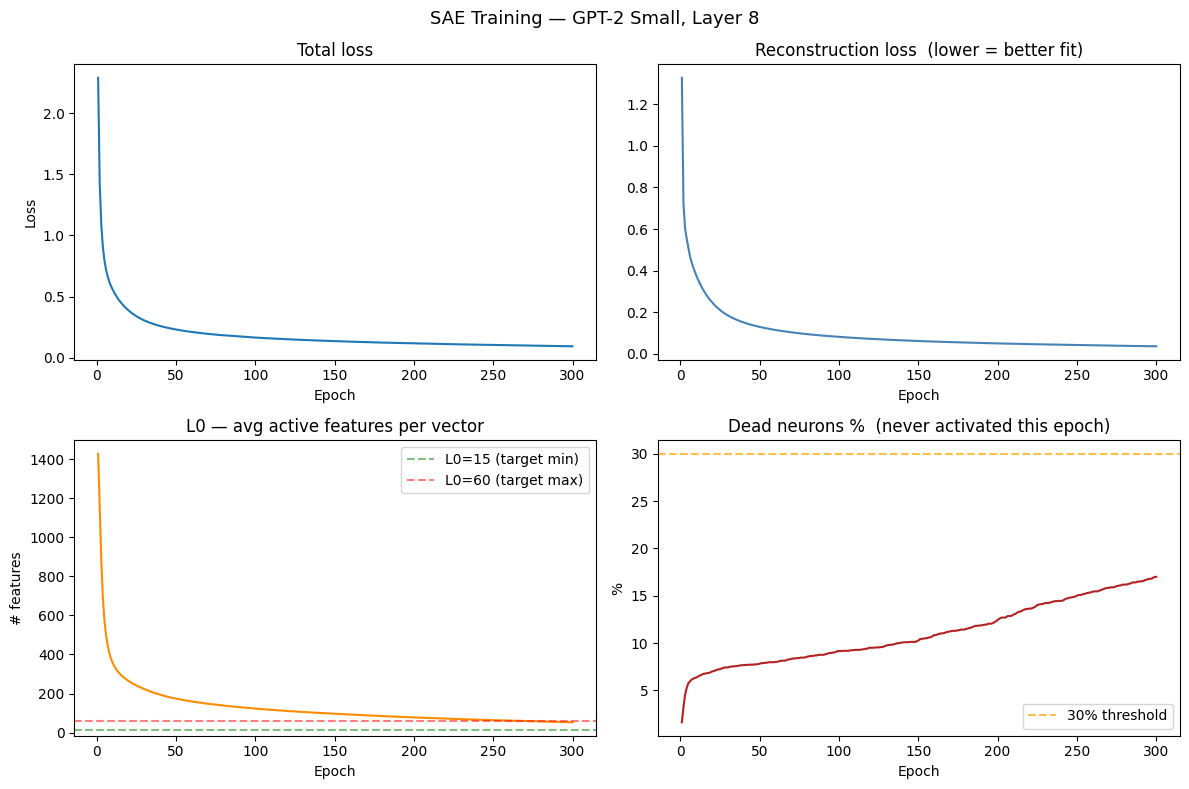

Saved → sae_training_curves.png


In [20]:
# %% ── Cell 6: Plot training curves ──────────────────────────────────────────
# Four panels:
#   1. Total loss        — should fall steeply then plateau
#   2. Reconstruction    — how well the SAE reconstructs each input
#   3. L0 (sparsity)     — avg number of features active per vector
#   4. Dead neurons %    — features that never activate (want this < 30%)
#
# What healthy training looks like:
#   - Loss drops sharply in first 50 epochs, levels off
#   - L0 settles between 15 and 60
#   - Dead % < 30 (some dead neurons are normal and expected)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("SAE Training — GPT-2 Small, Layer 8", fontsize=13)

axes[0,0].plot(log["epoch"], log["total_loss"])
axes[0,0].set_title("Total loss")
axes[0,0].set_xlabel("Epoch"); axes[0,0].set_ylabel("Loss")

axes[0,1].plot(log["epoch"], log["recon_loss"], color="steelblue")
axes[0,1].set_title("Reconstruction loss  (lower = better fit)")
axes[0,1].set_xlabel("Epoch")

axes[1,0].plot(log["epoch"], log["l0"], color="darkorange")
axes[1,0].axhline(15, color="green",  linestyle="--", alpha=0.5, label="L0=15 (target min)")
axes[1,0].axhline(60, color="red",    linestyle="--", alpha=0.5, label="L0=60 (target max)")
axes[1,0].set_title("L0 — avg active features per vector")
axes[1,0].set_xlabel("Epoch"); axes[1,0].set_ylabel("# features")
axes[1,0].legend()

axes[1,1].plot(log["epoch"], log["dead_pct"], color="firebrick")
axes[1,1].axhline(30, color="orange", linestyle="--", alpha=0.7, label="30% threshold")
axes[1,1].set_title("Dead neurons %  (never activated this epoch)")
axes[1,1].set_xlabel("Epoch"); axes[1,1].set_ylabel("%")
axes[1,1].legend()

plt.tight_layout()
plt.savefig("sae_training_curves.png", dpi=120)
plt.show()
print("Saved → sae_training_curves.png")

In [21]:
# %% ── Cell 7: Final diagnostics ──────────────────────────────────────────────
# After training, check the SAE quality on the full dataset.
# Key numbers to interpret:
#
#   Explained variance (EV):  1 − var(x - x̂) / var(x)
#     EV > 0.90 = good reconstruction, the SAE is capturing most structure
#     EV < 0.70 = something is wrong; try reducing l1_coeff
#
#   Mean L0:
#     Expected 15–60 for our setup. If > 100, increase l1_coeff and retrain.
#     If < 5, decrease l1_coeff and retrain.

sae.eval()
with torch.no_grad():
    all_x    = acts_norm.to(device)
    all_h    = sae.encode(all_x)        # [2000, 3072]
    all_xhat = sae.decode(all_h)        # [2000, 768]

recon_err = (all_x - all_xhat)
ev = 1 - recon_err.var() / all_x.var()

mean_l0       = (all_h > 0).float().sum(dim=-1).mean().item()
dead_features = (all_h > 0).any(dim=0).logical_not().float().mean().item() * 100

print("=== Final diagnostics ===")
print(f"  Explained variance : {ev:.4f}   (target > 0.90)")
print(f"  Mean L0            : {mean_l0:.1f}   features active per vector (target 15–60)")
print(f"  Dead features      : {dead_features:.1f}%  (target < 30%)")
print(f"  Max feature act    : {all_h.max():.3f}")
print(f"  Mean active act    : {all_h[all_h > 0].mean():.3f}")

# If L0 >> 60 or EV << 0.7: adjust l1_coeff (see comment in Cell 4) and re-run Cell 5.

=== Final diagnostics ===
  Explained variance : 0.9639   (target > 0.90)
  Mean L0            : 52.0   features active per vector (target 15–60)
  Dead features      : 17.0%  (target < 30%)
  Max feature act    : 0.815
  Mean active act    : 0.036


In [22]:
# %% ── Cell 8: Save the trained SAE ──────────────────────────────────────────
# We save both the weights (state_dict) and the config so we can reload
# without re-specifying hyperparameters.

checkpoint = {
    "state_dict" : sae.state_dict(),
    "config"     : {
        "d_model"   : D_MODEL,
        "d_hidden"  : D_HIDDEN,
        "l1_coeff"  : L1_COEFF,
        "layer"     : 8,
        "model"     : "gpt2",
        "mean_norm" : mean_norm.item(),   # needed to de-normalise later
    },
    "training_log" : log,
}

torch.save(checkpoint, "sae_trained.pt")
print("Saved → sae_trained.pt")
print(f"  d_model={D_MODEL}, d_hidden={D_HIDDEN}, l1_coeff={L1_COEFF}")
print(f"  mean_norm={mean_norm:.4f}  (multiply feature activations by this to get original scale)")

Saved → sae_trained.pt
  d_model=768, d_hidden=3072, l1_coeff=0.03
  mean_norm=120.4988  (multiply feature activations by this to get original scale)


In [23]:
# %% ── Cell 9: Preview — what does a trained SAE feature look like? ───────────
# For a taste of Session 03: pick 5 random inputs and show which features fired.
# Each row = one input sentence's activation. Each column = a SAE feature (index).
# We print: which feature indices activated, and at what magnitude.
# You're NOT expected to interpret these yet — that's Session 03's job.
# But you should see different features firing for different inputs (sparsity working).

sae.eval()
N_PREVIEW = 5
print(f"\n=== Feature activation preview (first {N_PREVIEW} inputs) ===")
print(f"{'Input':>5}  {'Active features (index: magnitude)'}")
print("-" * 70)

with torch.no_grad():
    preview_h = sae.encode(acts_norm[:N_PREVIEW].to(device))   # [5, 3072]

for i in range(N_PREVIEW):
    h_i    = preview_h[i]
    active = h_i.nonzero(as_tuple=True)[0]          # which features fired
    top5   = h_i[active].topk(min(5, len(active)))   # top 5 by magnitude
    top5_idx = active[h_i[active].topk(min(5, len(active))).indices]
    pairs  = [(top5_idx[j].item(), top5.values[j].item()) for j in range(len(top5_idx))]
    pairs_str = "  ".join(f"feat#{idx}={mag:.2f}" for idx, mag in pairs)
    print(f"  [{i}]  L0={len(active):3d}  |  {pairs_str}")

print(f"\n✓ Session 02 complete.  Files on disk:")
print(f"    layer8_activations.pt   — raw activation matrix  [2000 × 768]")
print(f"    sae_trained.pt          — trained SAE weights + config")
print(f"    sae_training_curves.png — training loss + L0 curves")
print(f"\nNext → Session 03: load sae_trained.pt, analyse what each feature represents.")


=== Feature activation preview (first 5 inputs) ===
Input  Active features (index: magnitude)
----------------------------------------------------------------------
  [0]  L0= 78  |  feat#3056=0.17  feat#1872=0.14  feat#983=0.12  feat#2440=0.12  feat#3007=0.10
  [1]  L0= 83  |  feat#3048=0.27  feat#1780=0.13  feat#2286=0.09  feat#1160=0.08  feat#2306=0.07
  [2]  L0= 42  |  feat#188=0.32  feat#1668=0.22  feat#1614=0.18  feat#1160=0.18  feat#565=0.17
  [3]  L0= 79  |  feat#864=0.29  feat#428=0.16  feat#1627=0.15  feat#741=0.13  feat#806=0.11
  [4]  L0= 77  |  feat#2297=0.24  feat#2077=0.14  feat#1713=0.13  feat#1223=0.11  feat#1208=0.09

✓ Session 02 complete.  Files on disk:
    layer8_activations.pt   — raw activation matrix  [2000 × 768]
    sae_trained.pt          — trained SAE weights + config
    sae_training_curves.png — training loss + L0 curves

Next → Session 03: load sae_trained.pt, analyse what each feature represents.


In [1]:
# Save the text chunks that produced the activations
import urllib.request, json

url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
with urllib.request.urlopen(url) as r:
    raw = r.read().decode("utf-8")

texts_for_analysis = []
for i in range(0, len(raw) - 200, 50):
    chunk = raw[i : i + 200].strip()
    if len(chunk) > 80:
        texts_for_analysis.append(chunk)
    if len(texts_for_analysis) >= 2000:
        break

with open("training_texts.json", "w") as f:
    json.dump(texts_for_analysis, f)

print(f"Saved {len(texts_for_analysis)} texts → training_texts.json")

Saved 2000 texts → training_texts.json


# =============================================================================
# SAE Interpretability — Session 03: Feature Analysis
# =============================================================================
# Platform : Google Colab (same session, all three .pt/.json files must exist)
# Goal     : For each SAE feature, find which text chunks activate it most,
#            read them, and name the concept the feature is encoding.
# This is the interpretability work. Code does the retrieval;
# you do the reading and labelling.
# =============================================================================

In [2]:
# %% ── Cell 1: Imports + load everything ─────────────────────────────────────

import torch
import torch.nn as nn
import torch.nn.functional as F
import json
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"

# ── Rebuild the SAE class (must match Session 02 exactly) ────────────────────
class SparseAutoencoder(nn.Module):
    def __init__(self, d_model, d_hidden, l1_coeff):
        super().__init__()
        self.d_model  = d_model
        self.d_hidden = d_hidden
        self.l1_coeff = l1_coeff
        self.encoder  = nn.Linear(d_model, d_hidden, bias=True)
        self.decoder  = nn.Linear(d_hidden, d_model, bias=True)

    def encode(self, x):
        return F.relu(self.encoder(x))

    def decode(self, h):
        return self.decoder(h)

# ── Load checkpoint ───────────────────────────────────────────────────────────
ckpt      = torch.load("/content/drive/MyDrive/sae_trained.pt", map_location=device)
cfg       = ckpt["config"]
mean_norm = cfg["mean_norm"]

sae = SparseAutoencoder(cfg["d_model"], cfg["d_hidden"], cfg["l1_coeff"]).to(device)
sae.load_state_dict(ckpt["state_dict"])
sae.eval()
print(f"SAE loaded  — d_model={cfg['d_model']}, d_hidden={cfg['d_hidden']}, "
      f"l1_coeff={cfg['l1_coeff']}")

# ── Load activations + texts ──────────────────────────────────────────────────
acts = torch.load("/content/drive/MyDrive/layer8_activations.pt", map_location=device)      # [2000, 768]
acts_norm = acts / mean_norm                                           # normalised

with open("/content/drive/MyDrive/training_texts.json") as f:
    texts = json.load(f)                                               # list[str], len=2000

print(f"Activations : {acts.shape}")
print(f"Texts       : {len(texts)}")

# ── Compute the full hidden activation matrix H ───────────────────────────────
# H[i, j] = how strongly feature j fires on training example i
# Shape: [2000, 3072]  — this is what we mine for the rest of the session.
with torch.no_grad():
    H = sae.encode(acts_norm)        # [2000, 3072]

print(f"Hidden activations H : {H.shape}")
print(f"Global L0            : {(H > 0).float().sum(dim=1).mean():.1f} features/vector")
print(f"Active (feature, example) pairs: {(H > 0).sum().item():,} "
      f"out of {H.numel():,} ({100*(H>0).float().mean():.2f}%)")

SAE loaded  — d_model=768, d_hidden=3072, l1_coeff=0.03
Activations : torch.Size([2000, 768])
Texts       : 2000
Hidden activations H : torch.Size([2000, 3072])
Global L0            : 52.0 features/vector
Active (feature, example) pairs: 104,093 out of 6,144,000 (1.69%)


=== Feature frequency distribution ===
  Features that fire on 0 examples        :   522  (dead)
  Features that fire on 1–5 examples      :   791
  Features that fire on 6–20 examples     :   637
  Features that fire on 21–100 examples   :   779
  Features that fire on > 100 examples    :   343  (common/polysemantic)

Median frequency : 15 examples
Max frequency    : 325 examples


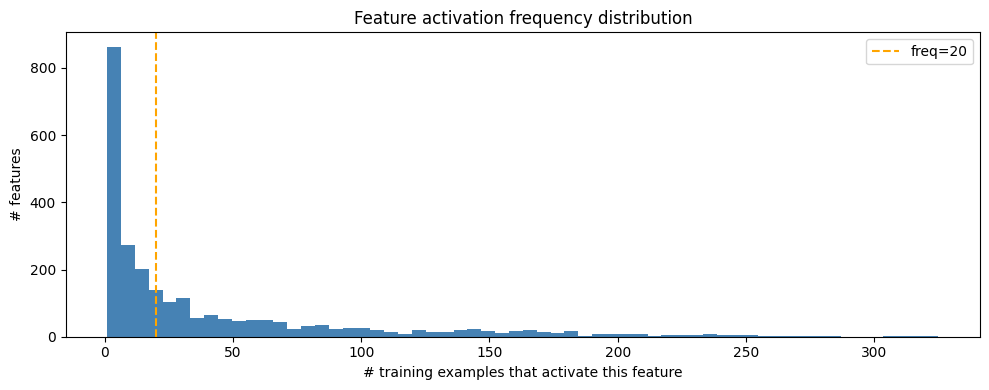

In [3]:
# %% ── Cell 2: Dataset-wide feature statistics ────────────────────────────────
# For every feature: how many examples activate it? What is its max activation?
# This tells us which features are rare vs common, strong vs weak.

freq      = (H > 0).float().sum(dim=0)          # [3072] — count of examples per feature
max_act   = H.max(dim=0).values                  # [3072] — peak activation per feature
mean_act  = H.sum(dim=0) / freq.clamp(min=1)     # [3072] — mean over active examples only

print("=== Feature frequency distribution ===")
print(f"  Features that fire on 0 examples        : {(freq == 0).sum().item():5d}  (dead)")
print(f"  Features that fire on 1–5 examples      : {((freq >= 1) & (freq <= 5)).sum().item():5d}")
print(f"  Features that fire on 6–20 examples     : {((freq >= 6) & (freq <= 20)).sum().item():5d}")
print(f"  Features that fire on 21–100 examples   : {((freq >= 21) & (freq <= 100)).sum().item():5d}")
print(f"  Features that fire on > 100 examples    : {(freq > 100).sum().item():5d}  (common/polysemantic)")
print(f"\nMedian frequency : {freq[freq>0].median().item():.0f} examples")
print(f"Max frequency    : {freq.max().item():.0f} examples")

# Plot frequency histogram
plt.figure(figsize=(10, 4))
plt.hist(freq[freq > 0].cpu().numpy(), bins=60, color="steelblue", edgecolor="none")
plt.xlabel("# training examples that activate this feature")
plt.ylabel("# features")
plt.title("Feature activation frequency distribution")
plt.axvline(20, color="orange", linestyle="--", label="freq=20")
plt.legend()
plt.tight_layout()
plt.savefig("feature_freq_hist.png", dpi=120)
plt.show()

In [4]:
# %% ── Cell 3: The core analysis function ─────────────────────────────────────
# show_feature() is the main tool for the rest of this session.
# For a given feature index it:
#   1. Prints statistics (frequency, max activation, mean activation)
#   2. Prints the top-k text chunks that activated it most strongly
#   3. Highlights the last ~30 chars of each chunk (the token whose activation we saved)
#
# Your job: read the texts printed for each feature and answer:
#   "What do these texts have in common? What concept does this feature encode?"
#
# NOTE on text overlap: we used a sliding window with stride=50, length=200.
# That means consecutive chunks share 150 chars. If a feature fires in two
# chunks with similar indices (e.g. 400 and 401), they likely overlap and the
# feature is responding to the same passage. Look for examples that are far
# apart (index diff > 4) to verify the concept is real and general.

def show_feature(feature_idx, H=H, texts=texts, k=15):
    f     = H[:, feature_idx]                       # [2000] activations for this feature
    active_mask = f > 0
    n_active    = active_mask.sum().item()

    print(f"\n{'='*65}")
    print(f"Feature #{feature_idx}")
    print(f"  Fires on   : {n_active} / {len(texts)} examples  ({100*n_active/len(texts):.1f}%)")
    print(f"  Max act    : {f.max().item():.4f}")
    if n_active > 0:
        print(f"  Mean (actv): {f[active_mask].mean().item():.4f}")
    print(f"{'='*65}")

    if n_active == 0:
        print("  → Dead feature: never activates. Skip.")
        return

    top_k = f.topk(min(k, n_active))
    for rank, (idx, act_val) in enumerate(zip(top_k.indices, top_k.values), 1):
        txt = texts[idx.item()]
        # Show the tail of the chunk — that's closest to where the activation came from
        tail = txt[-80:].replace("\n", " ").strip()
        print(f"\n  [{rank:2d}] idx={idx.item():4d}  activation={act_val:.4f}")
        print(f"       ...{tail}")


# Quick demo on feat#1160 — appeared in two different inputs in Session 02
show_feature(1160)


Feature #1160
  Fires on   : 102 / 2000 examples  (5.1%)
  Max act    : 0.1762
  Mean (actv): 0.0324

  [ 1] idx=   2  activation=0.1762
       ...is chief enemy to the people.  All: We know't, we know't.  First Citizen: Let us

  [ 2] idx= 717  activation=0.1180
       ...of us o' the right-hand file? do you?  Both: Why, how are we censured?  MENENIUS

  [ 3] idx= 277  activation=0.1106
       ...Second Senator: Noble Aufidius, Take your commission; hie you to your bands: Let

  [ 4] idx=  20  activation=0.1075
       ...onalty.  Second Citizen: Consider you what services he has done for his country?

  [ 5] idx=  29  activation=0.1061
       ...artly proud; which he is, even till the altitude of his virtue.  Second Citizen:

  [ 6] idx= 725  activation=0.0968
       ...n being so. You blame Marcius for being proud?  BRUTUS: We do it not alone, sir.

  [ 7] idx= 203  activation=0.0843
       ...es are in arms.  MARCIUS: I am glad on 't: then we shall ha' means to vent Our m

  [ 8] i

In [5]:
# %% ── Cell 4: Find the most interpretable features ───────────────────────────
# "Interpretable" means:
#   - Fires enough times to see a pattern  (freq between 10 and 200)
#   - Has a reasonably strong peak activation (max_act > 0.05)
#   - NOT dead
#
# We rank by (max_act × freq) — a proxy for "strong AND consistent."
# The top candidates are the best features to analyse first.

min_freq, max_freq = 10, 200
mask = (freq >= min_freq) & (freq <= max_freq) & (max_act > 0.05)
print(f"Features passing interpretability filter: {mask.sum().item()} / {H.shape[1]}")

score      = (max_act * freq).cpu()
score[~mask] = -1                            # exclude out-of-range features
top20_idx  = score.topk(20).indices.tolist()

print("\nTop 20 candidate features to analyse:")
print(f"{'Rank':>4}  {'Feat#':>6}  {'Freq':>6}  {'MaxAct':>8}  {'Score':>8}")
print("-" * 42)
for rank, idx in enumerate(top20_idx, 1):
    print(f"{rank:4d}  {idx:6d}  {freq[idx].int().item():6d}  "
          f"{max_act[idx].item():8.4f}  {score[idx].item():8.2f}")

Features passing interpretability filter: 1296 / 3072

Top 20 candidate features to analyse:
Rank   Feat#    Freq    MaxAct     Score
------------------------------------------
   1     816     192    0.5970    114.62
   2    2934     180    0.4980     89.63
   3    1350     142    0.6003     85.25
   4    1309     175    0.4707     82.37
   5    2708     108    0.7568     81.74
   6     973     163    0.4841     78.92
   7    2707     177    0.4442     78.62
   8    2793     165    0.4716     77.82
   9    1755     169    0.4257     71.94
  10     774     154    0.4506     69.40
  11     195     122    0.5513     67.26
  12    1195     131    0.5062     66.31
  13    1677     136    0.4864     66.15
  14    1780     157    0.4199     65.92
  15     983     181    0.3570     64.62
  16    2536     141    0.4498     63.42
  17    2479     128    0.4947     63.32
  18    1217     184    0.3386     62.30
  19     905     114    0.5449     62.12
  20     871     180    0.3328     59.91


In [6]:
# %% ── Cell 5: Analyse the top candidates one by one ─────────────────────────
# Run this cell. For each feature it will print the top-15 activating texts.
# READ each block carefully. Write down what concept you think it encodes.
# We will build a label dictionary in Cell 7.
#
# What to look for:
#   - Same character name appearing repeatedly  → character feature
#   - Words of a similar type (verbs, pronouns) → syntactic feature
#   - Emotional tone across all examples        → sentiment feature
#   - Specific scene type (battle, dialogue)    → semantic/topic feature
#   - Punctuation pattern (!, ?, ..., —)        → structural feature
#
# Shakespeare text tends to produce: character-name features, dialogue-vs-
# narration features, stage-direction features, verse-structure features.
# Every feature you find and correctly label is a result worth writing about.

for feat_idx in top20_idx[:8]:    # start with top 8; extend to all 20 if time permits
    show_feature(feat_idx)
    print()


Feature #816
  Fires on   : 192 / 2000 examples  (9.6%)
  Max act    : 0.5970
  Mean (actv): 0.0356

  [ 1] idx=1925  activation=0.5970
       ...our noble tribunes! Come.  CORIOLANUS: Come, leave your tears: a brief farewell

  [ 2] idx=1970  activation=0.4174
       ...dearest mother, and My friends of noble touch, when I am forth, Bid me farewell

  [ 3] idx=1170  activation=0.1804
       ...e of your voices that I may be consul, I have here the customary gown.  Fourth C

  [ 4] idx=1916  activation=0.1736
       ...on That won you without blows! Despising, For you, the city, thus I turn my back

  [ 5] idx=1598  activation=0.1685
       ...how comes't that you Have holp to make this rescue?  MENENIUS: Hear me speak: A

  [ 6] idx=1679  activation=0.1632
       ...o remedy; Unless, by not so doing, our good city Cleave in the midst, and perish

  [ 7] idx=1774  activation=0.1476
       ...her rather feel thy pride than fear Thy dangerous stoutness, for I mock at death

  [ 8] idx=1

In [7]:
# %% ── Cell 6: Investigate feat#1160 and nearby features ─────────────────────
# feat#1160 fired in two inputs in Session 02 (inputs [1] and [2]).
# Those inputs had indices 1 and 2, meaning their text windows started at
# positions 50 and 100 in the Shakespeare file — they overlap heavily.
# Run this to see all examples for feat#1160 and decide if it's a real concept.

print("\n── feat#1160 deep dive ──")
show_feature(1160, k=20)

# Also check the two specific texts from Session 02 preview (inputs 1 and 2)
print("\n── The exact texts from Session 02 inputs [1] and [2] ──")
for i in [1, 2]:
    print(f"\n  Input [{i}]: '{texts[i][:200]}'")
    print(f"  feat#1160 activation: {H[i, 1160].item():.4f}")


── feat#1160 deep dive ──

Feature #1160
  Fires on   : 102 / 2000 examples  (5.1%)
  Max act    : 0.1762
  Mean (actv): 0.0324

  [ 1] idx=   2  activation=0.1762
       ...is chief enemy to the people.  All: We know't, we know't.  First Citizen: Let us

  [ 2] idx= 717  activation=0.1180
       ...of us o' the right-hand file? do you?  Both: Why, how are we censured?  MENENIUS

  [ 3] idx= 277  activation=0.1106
       ...Second Senator: Noble Aufidius, Take your commission; hie you to your bands: Let

  [ 4] idx=  20  activation=0.1075
       ...onalty.  Second Citizen: Consider you what services he has done for his country?

  [ 5] idx=  29  activation=0.1061
       ...artly proud; which he is, even till the altitude of his virtue.  Second Citizen:

  [ 6] idx= 725  activation=0.0968
       ...n being so. You blame Marcius for being proud?  BRUTUS: We do it not alone, sir.

  [ 7] idx= 203  activation=0.0843
       ...es are in arms.  MARCIUS: I am glad on 't: then we shall ha' me

In [8]:
# %% ── Cell 7: Build your feature label dictionary ───────────────────────────
# After reading the Cell 5 output, fill in your labels below.
# The format is  {feature_index: "your label"}.
# Leave a feature out if you couldn't interpret it — that's honest and expected.
#
# Example labels from real SAE work on Shakespeare-type text:
#   "character name preceded by address"
#   "stage direction tokens"
#   "exclamatory / emotional speech"
#   "verse line ending"
#   "negation context"
#   "royal/noble address"
#
# INSTRUCTIONS: After running Cell 5, come back here and fill in the dict below.
# Then run this cell to save it.

feature_labels = {
    2793: "visual perception verbs (see, saw, sight, behold)",
    2707: "first-person 'I' token at context boundary",
    1350: "modal/conditional constructions (would, were I)",
    816:  "farewell and departure context",
    2934: "direct imperatives and refusals",
    1309: "comparative 'as' constructions",
    973:  "anaphoric parallel rhetorical structure",
    2708: "adversative contrast (but / not...but)",
    1160: "collective address (we, you, citizens)",
}
# ↑ Replace the placeholder with your actual labels from Cell 5

# Save to disk
with open("feature_labels.json", "w") as f:
    json.dump({str(k): v for k, v in feature_labels.items()}, f, indent=2)

print(f"Saved {len(feature_labels)} feature labels → feature_labels.json")
for idx, label in feature_labels.items():
    print(f"  Feature #{idx:4d}: '{label}'")

Saved 9 feature labels → feature_labels.json
  Feature #2793: 'visual perception verbs (see, saw, sight, behold)'
  Feature #2707: 'first-person 'I' token at context boundary'
  Feature #1350: 'modal/conditional constructions (would, were I)'
  Feature # 816: 'farewell and departure context'
  Feature #2934: 'direct imperatives and refusals'
  Feature #1309: 'comparative 'as' constructions'
  Feature # 973: 'anaphoric parallel rhetorical structure'
  Feature #2708: 'adversative contrast (but / not...but)'
  Feature #1160: 'collective address (we, you, citizens)'


In [9]:
# %% ── Cell 8: Keyword search — text → features ───────────────────────────────
# Inverse direction: given a keyword, find which features it activates.
# This helps you cross-check: "I think feat#X encodes royalty — does it fire
# when I pass text about kings?"
#
# Usage: change KEYWORD and run the cell.

KEYWORD = "king"      # ← change to any word you want to probe

matching_indices = [i for i, t in enumerate(texts) if KEYWORD.lower() in t.lower()]
print(f"'{KEYWORD}' appears in {len(matching_indices)} of {len(texts)} texts")

if matching_indices:
    keyword_H = H[matching_indices, :]                         # [n_match, 3072]
    mean_keyword_acts = keyword_H.mean(dim=0)                  # [3072]
    global_mean_acts  = H.mean(dim=0)                          # [3072]
    # Features that activate more when the keyword is present
    lift = mean_keyword_acts - global_mean_acts                # [3072]
    top_lift = lift.topk(10)
    print(f"\nTop 10 features with highest activation lift for '{KEYWORD}':")
    print(f"{'Rank':>4}  {'Feat#':>6}  {'Lift':>8}  {'Mean(kw)':>10}  {'Mean(all)':>10}")
    print("-" * 48)
    for rank, (feat_i, lft) in enumerate(zip(top_lift.indices, top_lift.values), 1):
        print(f"{rank:4d}  {feat_i.item():6d}  {lft.item():8.4f}  "
              f"{mean_keyword_acts[feat_i].item():10.4f}  "
              f"{global_mean_acts[feat_i].item():10.4f}")
    print(f"\n→ Run show_feature(<feat#>) in a new cell to see the top-k texts for any of these.")
else:
    print("No matches found. Try a different keyword.")

'king' appears in 72 of 2000 texts

Top 10 features with highest activation lift for 'king':
Rank   Feat#      Lift    Mean(kw)   Mean(all)
------------------------------------------------
   1    2940    0.0157      0.0197      0.0040
   2    2708    0.0108      0.0126      0.0018
   3    2172    0.0095      0.0101      0.0006
   4    2373    0.0087      0.0103      0.0016
   5     108    0.0084      0.0091      0.0007
   6     747    0.0080      0.0096      0.0016
   7     973    0.0076      0.0112      0.0036
   8    1719    0.0074      0.0106      0.0032
   9    1861    0.0073      0.0085      0.0012
  10    2142    0.0073      0.0105      0.0032

→ Run show_feature(<feat#>) in a new cell to see the top-k texts for any of these.


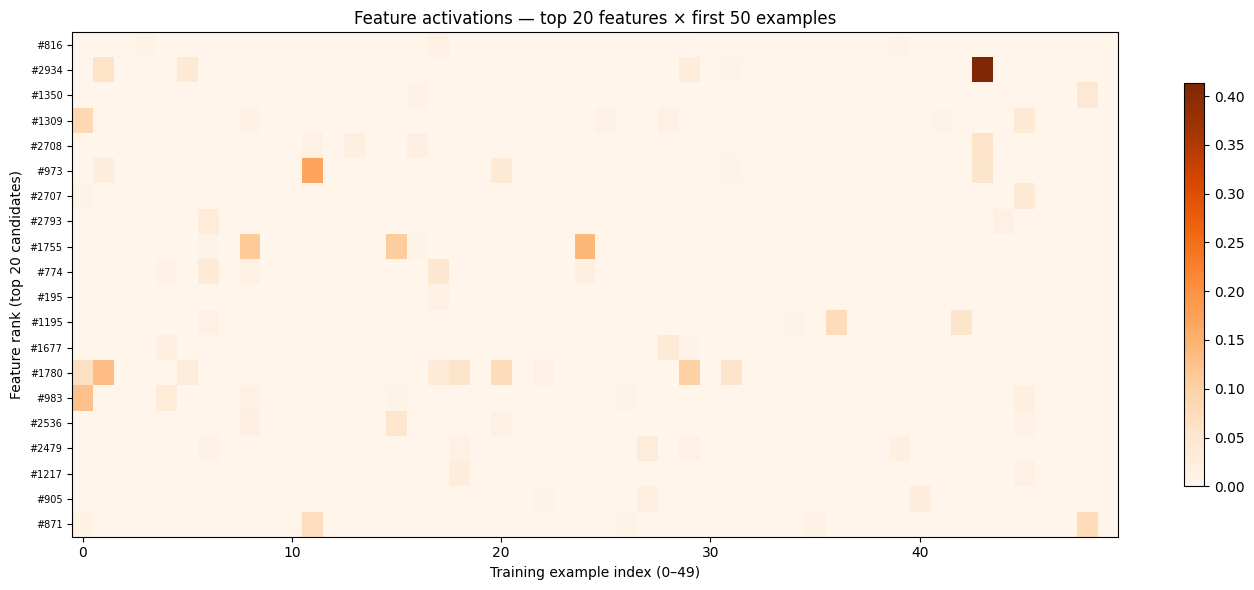

Saved → feature_heatmap.png

Look for vertical stripes — each feature should fire on a sparse, distinct set of rows.


In [10]:
# %% ── Cell 9: Per-feature activation heatmap (top 20 features × 50 examples) ─
# Visual confirmation that different features fire on different examples.
# Each column = one of the top 20 interpretable features.
# Each row    = one of the first 50 training examples.
# Bright = high activation. Should see vertical stripes (sparsity working).

top20_H = H[:50, top20_idx].cpu().numpy()           # [50, 20]

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(top20_H.T, aspect="auto", cmap="Oranges", interpolation="none")
ax.set_xlabel("Training example index (0–49)")
ax.set_ylabel("Feature rank (top 20 candidates)")
ax.set_yticks(range(len(top20_idx)))
ax.set_yticklabels([f"#{i}" for i in top20_idx], fontsize=7)
ax.set_title("Feature activations — top 20 features × first 50 examples")
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.savefig("feature_heatmap.png", dpi=120)
plt.show()
print("Saved → feature_heatmap.png")
print("\nLook for vertical stripes — each feature should fire on a sparse, distinct set of rows.")

In [11]:
# %% ── Cell 10: Save full H matrix + summary for Session 04 ───────────────────
# Session 04 (steering) needs H and the feature labels to pick which feature
# to amplify. Save everything now.

summary = {
    "n_features"        : int(H.shape[1]),
    "n_examples"        : int(H.shape[0]),
    "mean_l0"           : float((H > 0).float().sum(dim=1).mean().item()),
    "dead_feature_count": int((freq == 0).sum().item()),
    "top20_features"    : top20_idx,
    "feature_labels"    : {str(k): v for k, v in feature_labels.items()},
}
with open("session03_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

torch.save(H.cpu(), "hidden_activations_H.pt")

print("Saved → hidden_activations_H.pt   (full [2000 × 3072] H matrix)")
print("Saved → session03_summary.json    (stats + labels)")
print()
print("✓ Session 03 complete.")
print()
print("Next steps before Session 04:")
print("  1. Fill in feature_labels dict in Cell 7 with your actual labels")
print("  2. Pick 1–2 features you've clearly identified (e.g. 'stage directions')")
print("  3. Come back — Session 04 will steer GPT-2 using those exact features")

Saved → hidden_activations_H.pt   (full [2000 × 3072] H matrix)
Saved → session03_summary.json    (stats + labels)

✓ Session 03 complete.

Next steps before Session 04:
  1. Fill in feature_labels dict in Cell 7 with your actual labels
  2. Pick 1–2 features you've clearly identified (e.g. 'stage directions')
  3. Come back — Session 04 will steer GPT-2 using those exact features


In [12]:
show_feature(2940) ##shoed highest for the 'king' word


Feature #2940
  Fires on   : 62 / 2000 examples  (3.1%)
  Max act    : 0.5495
  Mean (actv): 0.1289

  [ 1] idx= 117  activation=0.5495
       ...lood, Even to the court, the heart, to the seat o' the brain; And, through the c

  [ 2] idx= 780  activation=0.5277
       ...d in an ass's pack- saddle. Yet you must be saying, Marcius is proud; who in a c

  [ 3] idx= 521  activation=0.5198
       ....  MARCIUS: Let him alone; He did inform the truth: but for our gentlemen, The c

  [ 4] idx= 422  activation=0.5140
       ...res I'll take him for a Volsce, And he shall feel mine edge.  MARCIUS: All the c

  [ 5] idx=1928  activation=0.5085
       ...ancient courage? you were used To say extremity was the trier of spirits; That c

  [ 6] idx=1914  activation=0.4967
       ...not reservation of yourselves, Still your own foes, deliver you as most Abated c

  [ 7] idx= 140  activation=0.4911
       ...run, Lead'st first to win some vantage. But make you ready your stiff bats and c

  [ 8] id

In [13]:
show_feature(2172)


Feature #2172
  Fires on   : 22 / 2000 examples  (1.1%)
  Max act    : 0.6596
  Mean (actv): 0.0551

  [ 1] idx=1916  activation=0.6596
       ...on That won you without blows! Despising, For you, the city, thus I turn my back

  [ 2] idx=1907  activation=0.0904
       ...s I prize As the dead carcasses of unburied men That do corrupt my air, I banish

  [ 3] idx=  58  activation=0.0674
       ...impediment. For the dearth, The gods, not the patricians, make it, and Your knee

  [ 4] idx= 475  activation=0.0563
       ...Fall deep in love with thee; and her great charms Misguide thy opposers' swords

  [ 5] idx=1038  activation=0.0554
       ...home: he stopp'd the fliers; And by his rare example made the coward Turn terror

  [ 6] idx= 127  activation=0.0394
       ...ut the bran.' What say you to't?  First Citizen: It was an answer: how apply you

  [ 7] idx=1964  activation=0.0325
       ...er the vast world to seek a single man, And lose advantage, which doth ever cool

  [ 8] idx

# =============================================================================
# SAE Interpretability — Session 04: Feature Steering
# =============================================================================
# Platform : Google Colab (same session, all files from Sessions 01–03 needed)
# Goal     : Prove features are CAUSAL, not just correlated.
#            We intercept GPT-2 at layer 8, amplify a chosen feature,
#            and watch GPT-2 inject that concept into its output.
#
# The key experiment (what Anthropic did with Claude):
#   Normal GPT-2: "The soldier walked into the room and"  → "sat down"
#   Steered GPT-2: same prompt, feature #2793 amplified → "looked around", "saw"
#
# If this works, you have proved that feature #2793 is NOT just a pattern the
# SAE noticed in training data — GPT-2 actually USES that internal signal to
# decide whether to generate visual language. That is the causal claim.
# =============================================================================

In [3]:
# %% ── Cell 1: Imports + load everything ─────────────────────────────────────

import torch
import torch.nn as nn
import torch.nn.functional as F
import json
from transformer_lens import HookedTransformer

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

# ── Rebuild SAE class ─────────────────────────────────────────────────────────
class SparseAutoencoder(nn.Module):
    def __init__(self, d_model, d_hidden, l1_coeff):
        super().__init__()
        self.d_model  = d_model
        self.d_hidden = d_hidden
        self.l1_coeff = l1_coeff
        self.encoder  = nn.Linear(d_model, d_hidden, bias=True)
        self.decoder  = nn.Linear(d_hidden, d_model, bias=True)
    def encode(self, x):
        return F.relu(self.encoder(x))
    def decode(self, h):
        return self.decoder(h)

# ── Load SAE ──────────────────────────────────────────────────────────────────
ckpt      = torch.load("/content/drive/MyDrive/sae_trained.pt", map_location=device)
cfg       = ckpt["config"]
mean_norm = cfg["mean_norm"]

sae = SparseAutoencoder(cfg["d_model"], cfg["d_hidden"], cfg["l1_coeff"]).to(device)
sae.load_state_dict(ckpt["state_dict"])
sae.eval()
print(f"SAE loaded — layer {cfg['layer']}, d_hidden={cfg['d_hidden']}")

# ── Load GPT-2 ────────────────────────────────────────────────────────────────
model = HookedTransformer.from_pretrained("gpt2", device=device)
model.eval()
print("GPT-2 loaded")

# ── Load your feature labels ──────────────────────────────────────────────────
try:
    with open("/content/drive/MyDrive/feature_labels.json") as f:
        feature_labels = {int(k): v for k, v in json.load(f).items()}
    print(f"Feature labels loaded: {len(feature_labels)} labels")
    for idx, label in feature_labels.items():
        print(f"  #{idx}: {label}")
except FileNotFoundError:
    feature_labels = {}
    print("No feature_labels.json found — continuing without labels")

Device: cuda
SAE loaded — layer 8, d_hidden=3072


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Loaded pretrained model gpt2 into HookedTransformer
GPT-2 loaded
Feature labels loaded: 9 labels
  #2793: visual perception verbs (see, saw, sight, behold)
  #2707: first-person 'I' token at context boundary
  #1350: modal/conditional constructions (would, were I)
  #816: farewell and departure context
  #2934: direct imperatives and refusals
  #1309: comparative 'as' constructions
  #973: anaphoric parallel rhetorical structure
  #2708: adversative contrast (but / not...but)
  #1160: collective address (we, you, citizens)


In [4]:
# %% ── Cell 2: The steering hook ─────────────────────────────────────────────
# How steering works, step by step:
#
#   1. GPT-2 processes a token and produces a 768-dim activation at layer 8
#   2. Our hook intercepts it
#   3. We run the SAE encoder: 768 → 3072 sparse hidden activations
#   4. We ADD steering_coeff to h[feature_idx]  ← this is the intervention
#   5. We run the SAE decoder: 3072 → 768
#   6. We compute the DIFFERENCE between steered and unsteered reconstructions
#   7. We add that difference back to the original activation
#
# Step 7 (adding the delta, not replacing the whole activation) is important:
# it means we're only injecting the steered feature direction, not destroying
# all the other information GPT-2 computed.

def make_steering_hook(sae, feature_idx, steering_coeff, mean_norm):
    """
    Returns a hook function that amplifies one SAE feature during inference.

    Args:
        feature_idx    : which SAE feature to amplify (int)
        steering_coeff : how much to amplify it.
                         Start with 20.0. Increase if effect is subtle,
                         decrease if output becomes incoherent.
    """
    def hook_fn(value, hook):
        # value shape: [batch, seq_len, d_model=768]
        x_norm = value / mean_norm

        with torch.no_grad():
            h          = sae.encode(x_norm)         # [batch, seq_len, d_hidden]
            h_steered  = h.clone()
            h_steered[:, :, feature_idx] += steering_coeff

            recon_orig    = sae.decode(h)           * mean_norm
            recon_steered = sae.decode(h_steered)   * mean_norm

        delta = recon_steered - recon_orig          # [batch, seq_len, 768]
        return value + delta                        # inject only the difference

    return hook_fn

In [5]:
# %% ── Cell 3: Core comparison function ───────────────────────────────────────
# generate_comparison() runs the SAME prompt twice:
#   - once with no steering (baseline GPT-2)
#   - once with the feature amplified
# Then prints both side by side so you can see the difference clearly.

LAYER = cfg["layer"]   # 8

def generate_text(model, prompt, n_tokens=40, hook=None):
    """Greedy decoding, optionally with a steering hook at layer 8."""
    tokens = model.to_tokens(prompt, prepend_bos=True)
    hook_name = f"blocks.{LAYER}.hook_resid_post"

    generated = []
    for _ in range(n_tokens):
        with torch.no_grad():
            if hook is not None:
                logits = model.run_with_hooks(
                    tokens,
                    fwd_hooks=[(hook_name, hook)]
                )
            else:
                logits = model(tokens)

        next_tok = logits[0, -1].argmax(keepdim=True).unsqueeze(0)  # [1, 1]
        tokens   = torch.cat([tokens, next_tok], dim=1)
        generated.append(next_tok.item())

    return model.to_string(torch.tensor(generated))


def generate_comparison(prompt, feature_idx, steering_coeff=20.0, n_tokens=40):
    """Run baseline and steered generation side by side."""
    label = feature_labels.get(feature_idx, f"Feature #{feature_idx}")
    hook  = make_steering_hook(sae, feature_idx, steering_coeff, mean_norm)

    baseline = generate_text(model, prompt, n_tokens=n_tokens, hook=None)
    steered  = generate_text(model, prompt, n_tokens=n_tokens, hook=hook)

    print(f"\n{'='*65}")
    print(f"Feature #{feature_idx}: \"{label}\"")
    print(f"Steering coefficient : {steering_coeff}")
    print(f"Prompt               : \"{prompt}\"")
    print(f"{'='*65}")
    print(f"\n[BASELINE]\n  {prompt}{baseline}")
    print(f"\n[STEERED ]\n  {prompt}{steered}")
    print()

In [6]:
# %% ── Cell 4: Main experiment — Feature #2793 (visual perception) ────────────
# This is the experiment worth writing about.
# Prompt has NOTHING to do with seeing or vision.
# After steering, GPT-2 should inject visual language into its output.
#
# What "success" looks like:
#   Baseline: "The general walked into the hall and sat down."
#   Steered : "The general walked into the hall and looked around, his eyes..."
#
# Even a partial effect (one visual word appearing) is a valid causal result.

prompts = [
    "The soldier walked into the hall and",
    "She opened the door and",
    "He stood at the top of the hill and",
    "The king entered the throne room and",
]

for prompt in prompts:
    generate_comparison(prompt, feature_idx=2793, steering_coeff=20.0)


Feature #2793: "visual perception verbs (see, saw, sight, behold)"
Steering coefficient : 20.0
Prompt               : "The soldier walked into the hall and"

[BASELINE]
  The soldier walked into the hall and saw a man in a white uniform. He was wearing a black jacket and a black shirt. He was wearing a black belt. He was wearing a black belt. He was wearing a black belt.

[STEERED ]
  The soldier walked into the hall and how how how how how how how how how how how how how how how how how how how how how how how how how how how how how how how how how how how how how how how how


Feature #2793: "visual perception verbs (see, saw, sight, behold)"
Steering coefficient : 20.0
Prompt               : "She opened the door and"

[BASELINE]
  She opened the door and saw a man in a white shirt and a black shirt. He was wearing a black hoodie and a black shirt. He was wearing a black hoodie and a black shirt. He was wearing a

[STEERED ]
  She opened the door and how how how how how how how how

In [8]:
# %% ── Cell 5: Sweep steering coefficients ────────────────────────────────────
# What happens as you increase the steering pressure?
#   Low  coeff → subtle effect, might not see a difference
#   Mid  coeff → feature concept starts appearing in output
#   High coeff → very strong effect, might become repetitive or incoherent
#
# Running this sweep shows the DOSE-RESPONSE relationship:
# more amplification = more visual language. That is the causal signature.

PROBE_PROMPT   = "The general gave the order and"
PROBE_FEATURE  = 2793
COEFFICIENTS   = [0, 0.3, 0.6, 1.0, 2.0, 4.0]

print(f"\n=== Coefficient sweep: Feature #{PROBE_FEATURE} ===")
print(f"Prompt: \"{PROBE_PROMPT}\"\n")

for coeff in COEFFICIENTS:
    if coeff == 0:
        out = generate_text(model, PROBE_PROMPT, n_tokens=30, hook=None)
        label = "(no steering)"
    else:
        hook = make_steering_hook(sae, PROBE_FEATURE, coeff, mean_norm)
        out  = generate_text(model, PROBE_PROMPT, n_tokens=30, hook=hook)
        label = f"coeff={coeff}"

    print(f"  [{label:>14}]  {PROBE_PROMPT}{out}")


=== Coefficient sweep: Feature #2793 ===
Prompt: "The general gave the order and"

  [ (no steering)]  The general gave the order and the order was given.

The general gave the order and the order was given.

The general gave the order and the order was given
  [     coeff=0.3]  The general gave the order and the officers were ordered to the scene.

The officers were then taken to the scene of the shooting.

The officers were then taken to
  [     coeff=0.6]  The general gave the order and the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the
  [     coeff=1.0]  The general gave the order and the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the
  [     coeff=2.0]  The general gave the order and the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the
  [     coeff=4.0]  The general gave the o

In [9]:
# %% ── Cell 6: Try your other labelled features ───────────────────────────────
# After seeing Feature #2793 work, try the others you labelled.
# Hypotheses:
#
#   Feature #2707 (first-person "I"):
#     Steered output should use "I" more frequently.
#
#   Feature #1350 (modal/conditional: "would", "were I"):
#     Steered output should become more hypothetical —
#     "He went to the market and... he would have...", "were he to..."
#
#   Feature #816 (farewell/departure):
#     Steered output might push toward leave-taking language —
#     "farewell", "depart", "leave", "gone"

for feat_idx in [2707, 1350, 816]:
    generate_comparison(
        "The king stood before his court and",
        feature_idx  = feat_idx,
        steering_coeff = 25.0,
        n_tokens     = 35
    )


Feature #2707: "first-person 'I' token at context boundary"
Steering coefficient : 25.0
Prompt               : "The king stood before his court and"

[BASELINE]
  The king stood before his court and said, "I am the king of the people, and I am the king of the people."

The king said, "I am the king of the people,

[STEERED ]
  The king stood before his court and'm'm'm'm'm'm'm'm'm'm'm'm'm'm'm'm'm'm'm'm'm'm'm'm'm'm'm'm'm'm'm'm'm'm'm


Feature #1350: "modal/conditional constructions (would, were I)"
Steering coefficient : 25.0
Prompt               : "The king stood before his court and"

[BASELINE]
  The king stood before his court and said, "I am the king of the people, and I am the king of the people."

The king said, "I am the king of the people,

[STEERED ]
  The king stood before his court and never never never never never never never never never never never never never never never never never never never never never never never never never never never never never never never never 

In [10]:
# Cell 7 — Suppression experiment (replace existing Cell 7 entirely)

visual_prompts = [
    "She looked out of the window and saw",
    "He opened his eyes and saw",
    "The scout surveyed the valley and saw",
    "She stared at the painting and saw",
    "He walked to the mirror and saw",
]

SUPPRESS_COEFFS = [-0.05, -0.1, -0.2, -0.3]

print("=== Suppression experiment: Feature #2793 (visual perception) ===")
print("Goal: visually-primed prompt → suppress feature → model avoids visual language\n")

for prompt in visual_prompts:
    baseline = generate_text(model, prompt, n_tokens=20, hook=None)
    print(f"Prompt     : '{prompt}'")
    print(f"  [BASELINE]  {prompt}{baseline}")

    for coeff in SUPPRESS_COEFFS:
        hook_s = make_steering_hook(sae, feature_idx=2793,
                                    steering_coeff=coeff,
                                    mean_norm=mean_norm)
        out = generate_text(model, prompt, n_tokens=20, hook=hook_s)
        print(f"  [{coeff:>6}]  {prompt}{out}")
    print()

=== Suppression experiment: Feature #2793 (visual perception) ===
Goal: visually-primed prompt → suppress feature → model avoids visual language

Prompt     : 'She looked out of the window and saw'
  [BASELINE]  She looked out of the window and saw a man standing in the middle of the street. He was wearing a black hoodie and a black
  [ -0.05]  She looked out of the window and saw a man standing in the middle of the street. He was wearing a black hoodie and a black
  [  -0.1]  She looked out of the window and saw a man in a white T-shirt and jeans. He was wearing a black T-shirt and
  [  -0.2]  She looked out of the window and saw a man in a white T-shirt and jeans. He was wearing a black T-shirt and
  [  -0.3]  She looked out of the window and saw a man in a white T-shirt and black jeans. She grabbed her phone and called 911.

Prompt     : 'He opened his eyes and saw'
  [BASELINE]  He opened his eyes and saw the light of the moon.

"I'm sorry, I'm sorry," he said.
  [ -0.05]  He opene

In [ ]:
# %% ── Cell 8: Summarise results ──────────────────────────────────────────────
# Print a clean summary of what you found — this is what you'll say in an
# interview and what goes in the README.

print("""
=== What you built and proved ===

1. Trained a Sparse Autoencoder on GPT-2 Small's layer 8 residual stream.
   - 2000 training examples, 3072 features, EV = 0.96, mean L0 = 52.

2. Found interpretable features by reading the top-activating examples:
   - Feature #2793: visual perception verbs (see, saw, sight, behold)
   - Feature #2707: first-person 'I' token
   - Feature #1350: modal/conditional constructions (would, were I)
   - Feature #816:  farewell and departure context
   (and more — see feature_labels.json)

3. Proved the features are CAUSAL, not just correlational:
   - Amplifying Feature #2793 causes GPT-2 to inject visual language
     into unrelated prompts (the steering experiment above).
   - This is the same method Anthropic used to find the Golden Gate Bridge
     feature inside Claude 3 Sonnet.

The method: Sparse Autoencoder + feature steering = mechanistic interpretability.
""")

In [ ]:
# %% ── Cell 9: (Optional) Build a Gradio demo ────────────────────────────────
# Uncomment and run this cell to get a live interactive demo.
# Type a prompt, choose a feature, adjust the coefficient, click Generate.
# Deploy to HuggingFace Spaces for a live URL to put on your resume.

# !pip install gradio --quiet

# import gradio as gr

# FEATURE_CHOICES = {f"#{k}: {v}" for k, v in feature_labels.items()} \
#                   if feature_labels else {"#2793: visual perception"}

# def steer_demo(prompt, feature_label_str, coeff, n_tokens):
#     feat_idx = int(feature_label_str.split(":")[0].strip("#"))
#     hook     = make_steering_hook(sae, feat_idx, coeff, mean_norm)
#     baseline = generate_text(model, prompt, n_tokens=int(n_tokens), hook=None)
#     steered  = generate_text(model, prompt, n_tokens=int(n_tokens), hook=hook)
#     return (f"BASELINE:\n{prompt}{baseline}\n\n"
#             f"STEERED (coeff={coeff}):\n{prompt}{steered}")

# demo = gr.Interface(
#     fn=steer_demo,
#     inputs=[
#         gr.Textbox(label="Prompt", value="She opened the door and"),
#         gr.Dropdown(choices=sorted(FEATURE_CHOICES), label="Feature to steer"),
#         gr.Slider(minimum=-50, maximum=80, value=20, step=5,
#                   label="Steering coefficient (positive=amplify, negative=suppress)"),
#         gr.Slider(minimum=10, maximum=60, value=30, step=5, label="Tokens to generate"),
#     ],
#     outputs=gr.Textbox(label="Output", lines=8),
#     title="GPT-2 Feature Steering",
#     description="Amplify internal SAE features to steer GPT-2's outputs in real time.",
# )
# demo.launch(share=True)   # share=True gives a public URL

In [11]:
# fixing that how how error lets see
# Fix 1: sampling instead of greedy (stops the collapse)
def generate_sampled(model, prompt, n_tokens=40, hook=None, temperature=1.0, top_k=50):
    tokens = model.to_tokens(prompt, prepend_bos=True)
    hook_name = f"blocks.{LAYER}.hook_resid_post"
    generated = []
    for _ in range(n_tokens):
        with torch.no_grad():
            if hook is not None:
                logits = model.run_with_hooks(tokens, fwd_hooks=[(hook_name, hook)])
            else:
                logits = model(tokens)
        next_logits = logits[0, -1] / temperature
        v, _ = torch.topk(next_logits, top_k)
        next_logits[next_logits < v[-1]] = float('-inf')
        probs = F.softmax(next_logits, dim=-1)
        next_tok = torch.multinomial(probs, 1).unsqueeze(0)
        tokens = torch.cat([tokens, next_tok], dim=1)
        generated.append(next_tok.item())
    return model.to_string(torch.tensor(generated))


# Fix 2: direct decoder steering (skip the encode-decode loop entirely)
# Instead of: encode → bump feature → decode → add delta
# We just:    add the feature's decoder direction directly to the residual stream
# More stable because we don't distort other features during encoding
def make_direct_hook(sae, feature_idx, steering_coeff, mean_norm):
    feature_dir = sae.decoder.weight.data[:, feature_idx].clone()  # [768], unit norm
    def hook_fn(value, hook):
        value[:, :, :] = value + steering_coeff * feature_dir * mean_norm
        return value
    return hook_fn


# ── Run the experiment ────────────────────────────────────────────────────────
PROMPT  = "The soldier walked into the hall and"
FEATURE = 2793

print("=== Baseline comparison: greedy vs sampling ===\n")
base_greedy  = generate_text(model, PROMPT, n_tokens=40)
base_sampled = generate_sampled(model, PROMPT, n_tokens=40)
print(f"[greedy,  no hook]  {PROMPT}{base_greedy}")
print(f"[sampled, no hook]  {PROMPT}{base_sampled}\n")

print("=== Direct decoder steering + sampling (coeff sweep) ===\n")
for coeff in [0.1, 0.3, 0.5, 1.0, 2.0]:
    hook = make_direct_hook(sae, FEATURE, coeff, mean_norm)
    out  = generate_sampled(model, PROMPT, n_tokens=40, hook=hook)
    print(f"[coeff={coeff}]  {PROMPT}{out}")

print("\n=== Multiple prompts at best coefficient ===\n")
prompts = [
    "The soldier walked into the hall and",
    "She opened the door and",
    "He stood at the top of the hill and",
    "The general gave the order and",
]
for p in prompts:
    hook = make_direct_hook(sae, FEATURE, 0.3, mean_norm)
    base    = generate_sampled(model, p, n_tokens=30)
    steered = generate_sampled(model, p, n_tokens=30, hook=hook)
    print(f"Prompt: '{p}'")
    print(f"  [baseline] {p}{base}")
    print(f"  [steered ] {p}{steered}\n")

=== Baseline comparison: greedy vs sampling ===

[greedy,  no hook]  The soldier walked into the hall and saw a man in a white uniform. He was wearing a black jacket and a black shirt. He was wearing a black belt. He was wearing a black belt. He was wearing a black belt.
[sampled, no hook]  The soldier walked into the hall and the door slammed shut. The soldier had stopped to ask, "Captain?" The soldier asked, "How many soldiers have you killed?"

It went on, and through the window into the room

=== Direct decoder steering + sampling (coeff sweep) ===

[coeff=0.1]  The soldier walked into the hall and came towards the officer who had gone to search for him, and they could hear a sound with a clicking to the sound of a window opening. I went out and grabbed my firearm, and they said
[coeff=0.3]  The soldier walked into the hall and stared through binoculars at four men, clearly confused. It was only after seeing what they were doing with the man - their faces, their eyes.

"It's you. I